<a href="https://colab.research.google.com/github/debashistripathy-riku/LMS_celebal_weekly_Assignment/blob/main/week3_DEBASHIS_TRIPATHY_SOA_University.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Intelligence & Country Segmentation System
### End-to-End Hybrid ML Pipeline (Clustering, Ensemble & Classification)

This self-contained notebook is designed to run in **Google Colab**. It loads the country socio-economic dataset directly from a public URL, performs preprocessing, clustering (K-Means & DBSCAN), and trains ensemble classifiers (Random Forest & XGBoost) on the discovered segments.

In [1]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, silhouette_score
from sklearn.preprocessing import LabelEncoder

# Style config
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load Dataset from Public URL

In [3]:
dataset_url = "https://raw.githubusercontent.com/vatsalmandalia/Country-Data-Kmeans-Clustering/master/Country-data.csv"
df = pd.read_csv(dataset_url)

print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns.")
df.head()

Loaded dataset: 167 rows, 10 columns.


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3. Exploratory Data Analysis (EDA)
Let's see some basic summary stats and correlations.

In [4]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


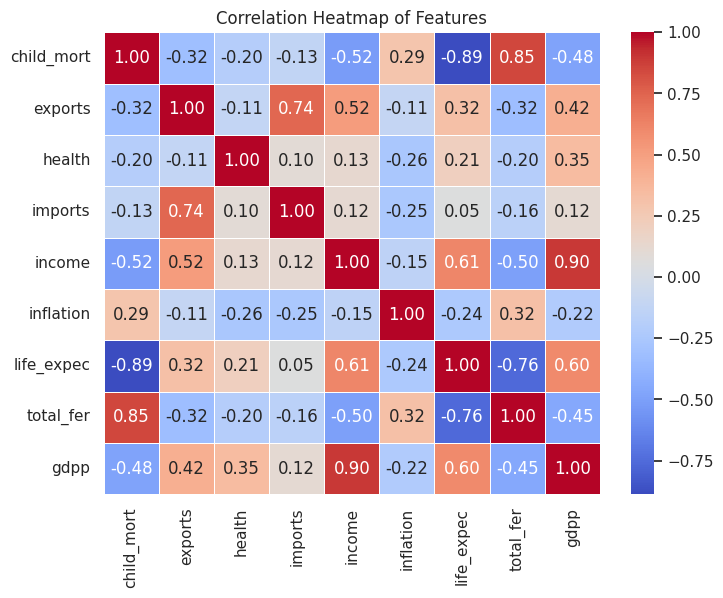

In [5]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.show()

## 4. Preprocessing & Feature Engineering
In the raw dataset, `exports`, `health`, and `imports` are given as a percentage of `gdpp`. We convert them to absolute per capita dollar values to avoid scale mismatches, then scale all variables.

In [6]:
# 1. Convert columns to absolute values
df_proc = df.copy()
df_proc['exports'] = (df_proc['exports'] * df_proc['gdpp']) / 100.0
df_proc['health'] = (df_proc['health'] * df_proc['gdpp']) / 100.0
df_proc['imports'] = (df_proc['imports'] * df_proc['gdpp']) / 100.0

# 2. Extract numerical features
feature_cols = ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
X = df_proc[feature_cols]

# 3. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print("Scaled Features Preview:")
X_scaled_df.head()

Scaled Features Preview:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-0.411011,-0.565040,-0.432276,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.350191,-0.439218,-0.313677,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.318526,-0.484826,-0.353720,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,-0.291375,-0.532363,-0.345953,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,-0.104331,-0.178771,0.040735,0.101732,-0.601749,0.704258,-0.541946,-0.041817


### Dimensionality Reduction (PCA)
Reducing the features to 2 principal components to visualize clusters easily.

In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

Explained variance ratio: [0.58937298 0.18445169]


## 5. Unsupervised Clustering

### 5.1 K-Means Clustering
We use Elbow method (inertia) and Silhouette Analysis to check $K=3$.

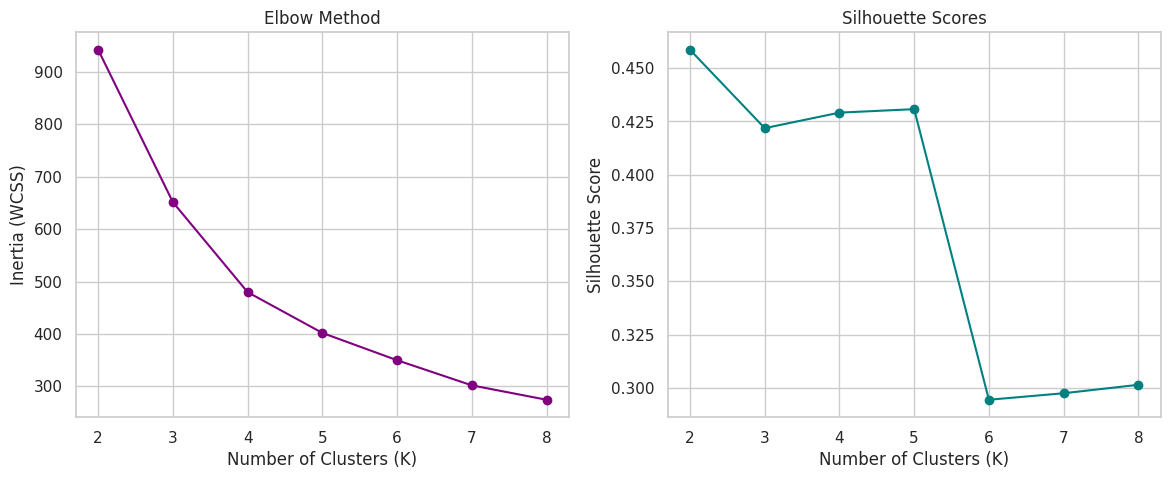

In [8]:
wcss = []
sil_scores = []
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(range(2, 9), wcss, marker='o', color='purple')
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (WCSS)')

ax2.plot(range(2, 9), sil_scores, marker='o', color='teal')
ax2.set_title('Silhouette Scores')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
plt.show()

### Fit K-Means ($K=3$) and Profiling
Let's map the clusters to logical segments based on mean GDP per capita values.

In [9]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
raw_labels = kmeans.fit_predict(X_scaled)

df_proc['kmeans_cluster'] = raw_labels

# Programmatic profiling map: sort by mean gdpp
cluster_profiles = df_proc.groupby('kmeans_cluster')['gdpp'].mean().sort_values().index
label_map = {cluster_profiles[0]: 'Underdeveloped',
             cluster_profiles[1]: 'Developing',
             cluster_profiles[2]: 'Developed'}

df_proc['development_segment'] = df_proc['kmeans_cluster'].map(label_map)
df_pca['segment'] = df_proc['development_segment']

print("Cluster Counts:")
print(df_proc['development_segment'].value_counts())
df_proc.groupby('development_segment')[['gdpp', 'child_mort', 'income']].mean()

Cluster Counts:
development_segment
Developing        91
Underdeveloped    48
Developed         28
Name: count, dtype: int64


,gdpp,child_mort,income
development_segment,,,
Developed,48114.285714,5.046429,50178.571429
Developing,7979.912088,20.357143,13968.021978
Underdeveloped,1909.208333,91.610417,3897.354167


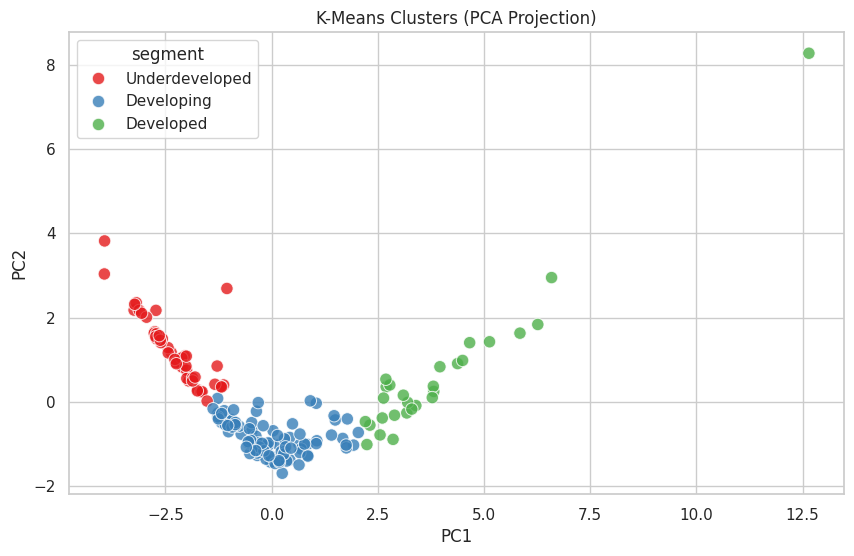

In [10]:
# Plot the K-Means clusters on PCA Projection
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='segment', palette='Set1', s=80, alpha=0.8)
plt.title('K-Means Clusters (PCA Projection)')
plt.show()

### 5.2 DBSCAN Clustering
Used to identify outliers that differ from the typical cluster density regions.

In [11]:
dbscan = DBSCAN(eps=1.8, min_samples=3)
db_labels = dbscan.fit_predict(X_scaled)
df_proc['dbscan_cluster'] = db_labels
df_proc['dbscan_segment'] = ['Outlier' if l == -1 else f'Cluster_{l}' for l in db_labels]

print("DBSCAN Cluster counts:")
print(df_proc['dbscan_segment'].value_counts())

DBSCAN Cluster counts:
dbscan_segment
Cluster_0    156
Outlier       11
Name: count, dtype: int64


## 6. Supervised Ensemble Classification
We use the K-Means segments as pseudo-labels to train **Random Forest** and **XGBoost** classifiers.

In [12]:
# Prepare data
le = LabelEncoder()
y = le.fit_transform(df_proc['development_segment'])

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 1. Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# 2. XGBoost
xgb = XGBClassifier(n_estimators=100, max_depth=3, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("Random Forest Test Accuracy:", accuracy_score(y_test, rf_pred))
print("XGBoost Test Accuracy:", accuracy_score(y_test, xgb_pred))

Random Forest Test Accuracy: 0.9411764705882353
XGBoost Test Accuracy: 1.0


In [13]:
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, rf_pred, target_names=le.classes_))

print("--- XGBoost Classification Report ---")
print(classification_report(y_test, xgb_pred, target_names=le.classes_))

--- Random Forest Classification Report ---
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         6
    Developing       0.94      0.94      0.94        18
Underdeveloped       0.90      0.90      0.90        10

      accuracy                           0.94        34
     macro avg       0.95      0.95      0.95        34
  weighted avg       0.94      0.94      0.94        34

--- XGBoost Classification Report ---
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         6
    Developing       1.00      1.00      1.00        18
Underdeveloped       1.00      1.00      1.00        10

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



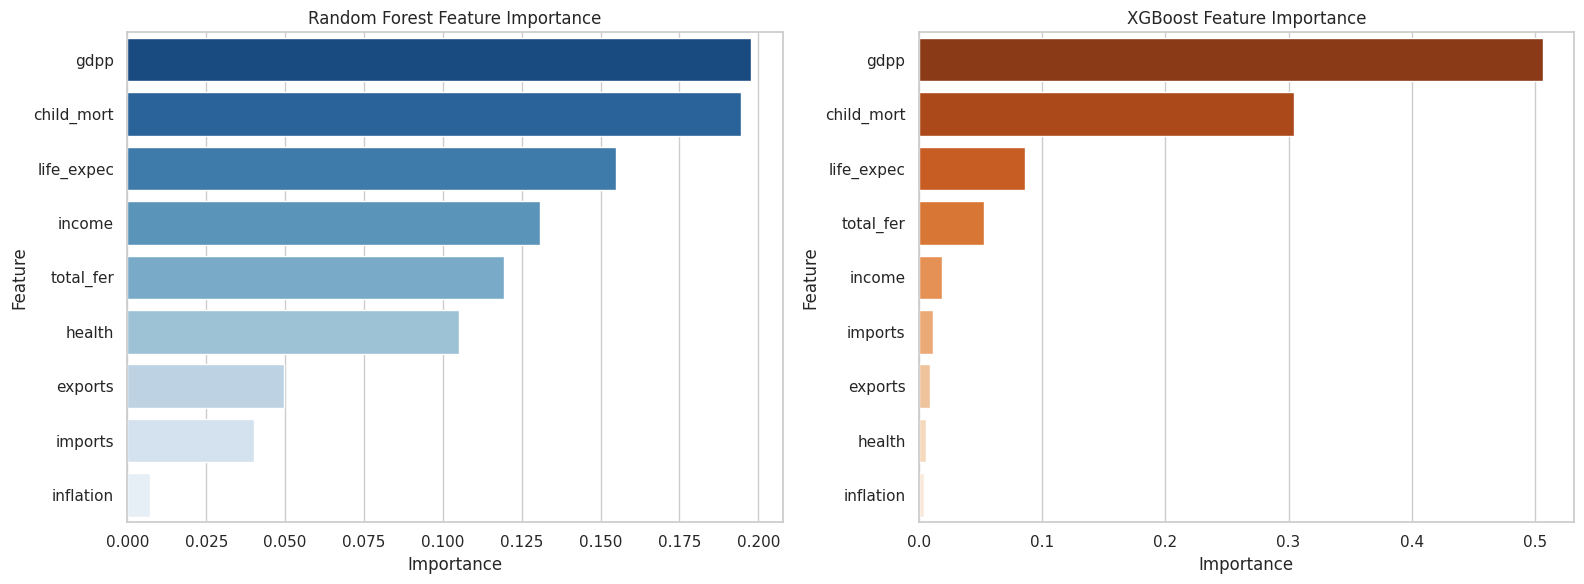

In [14]:
# Feature Importance Comparison
rf_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)
xgb_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': xgb.feature_importances_}).sort_values(by='Importance', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=rf_imp, x='Importance', y='Feature', hue='Feature', palette='Blues_r', legend=False, ax=ax1)
ax1.set_title('Random Forest Feature Importance')

sns.barplot(data=xgb_imp, x='Importance', y='Feature', hue='Feature', palette='Oranges_r', legend=False, ax=ax2)
ax2.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

## 7. Real-Time Inference Console
Edit the variables below and run the cell to predict the segment of a new custom country.

In [15]:
# Input custom country metrics below
custom_country = {
    'child_mort': 32.0,
    'exports': 20.0,    # as % of gdpp
    'health': 5.5,      # as % of gdpp
    'imports': 30.0,    # as % of gdpp
    'income': 18000,
    'inflation': 4.5,
    'life_expec': 72.0,
    'total_fer': 2.3,
    'gdpp': 12000
}

# 1. Convert percentage features to absolute values
cc_df = pd.DataFrame([custom_country])
cc_df['exports'] = (cc_df['exports'] * cc_df['gdpp']) / 100.0
cc_df['health'] = (cc_df['health'] * cc_df['gdpp']) / 100.0
cc_df['imports'] = (cc_df['imports'] * cc_df['gdpp']) / 100.0

# 2. Scale features
scaled_cc = scaler.transform(cc_df[feature_cols])

# 3. Predict segment
pred_class = xgb.predict(scaled_cc)
pred_label = le.inverse_transform(pred_class)[0]

print(f"Predicted Segment: {pred_label}")

Predicted Segment: Developing
